In [ ]:
!sudo apt-get update -qq
!sudo apt-get install -y iverilog gtkwave

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libjudydebian1 librsvg2-common libxcomposite1
Suggested packages:
  gvfs
The following NEW packages will be installed:
  gtkwave iverilog libatk1.0-0 libatk1.0-data libgail-common libgail18
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libjudydebian1 librsvg2-common
  libxcomposite1
0 upgraded, 12 newly installed, 0 to remove and 44 not upgraded.
Need to get 7,069 kB of archives.
After this operation, 18.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.0-common all 2.24.33-2ubuntu2.1 [125 kB

In [ ]:
!mkdir -p FPGA-Traffic-Light-Controller/{rtl,tb,simulation,waveforms,reports}
%cd FPGA-Traffic-Light-Controller

/content/FPGA-Traffic-Light-Controller


In [ ]:
%%writefile rtl/traffic_light_controller.v

module traffic_light_controller #(
    parameter GREEN_TIME  = 10,
    parameter YELLOW_TIME = 3,
    parameter ALL_RED_TIME = 2
)(
    input wire clk,
    input wire rst,

    input wire veh_ns,
    input wire veh_ew,
    input wire pedestrian_request,
    input wire emergency,
    input wire night_mode,

    output reg ns_green,
    output reg ns_yellow,
    output reg ns_red,

    output reg ew_green,
    output reg ew_yellow,
    output reg ew_red,

    output reg ped_walk,
    output reg ped_dont_walk
);

    localparam NS_GREEN   = 3'd0;
    localparam NS_YELLOW  = 3'd1;
    localparam ALL_RED_1  = 3'd2;
    localparam EW_GREEN   = 3'd3;
    localparam EW_YELLOW  = 3'd4;
    localparam ALL_RED_2  = 3'd5;
    localparam EMERGENCY  = 3'd6;
    localparam NIGHT_MODE = 3'd7;

    reg [2:0] state;
    reg [15:0] counter;
    reg ped_request_latched;
    reg blink;

    always @(posedge clk) begin
        if (rst) begin
            state <= NS_GREEN;
            counter <= 0;
            ped_request_latched <= 0;
            blink <= 0;
        end else begin

            if (pedestrian_request)
                ped_request_latched <= 1;

            if (emergency)
                state <= EMERGENCY;
            else if (night_mode)
                state <= NIGHT_MODE;

            case (state)

                NS_GREEN: begin
                    if (counter < GREEN_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= NS_YELLOW;
                    end
                end

                NS_YELLOW: begin
                    if (counter < YELLOW_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= ALL_RED_1;
                    end
                end

                ALL_RED_1: begin
                    if (counter < ALL_RED_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= EW_GREEN;
                    end
                end

                EW_GREEN: begin
                    if (counter < GREEN_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= EW_YELLOW;
                    end
                end

                EW_YELLOW: begin
                    if (counter < YELLOW_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= ALL_RED_2;
                    end
                end

                ALL_RED_2: begin
                    if (counter < ALL_RED_TIME)
                        counter <= counter + 1;
                    else begin
                        counter <= 0;
                        state <= NS_GREEN;
                        ped_request_latched <= 0;
                    end
                end

                EMERGENCY: begin
                    counter <= 0;
                    if (!emergency)
                        state <= NS_GREEN;
                end

                NIGHT_MODE: begin
                    blink <= ~blink;
                    if (!night_mode)
                        state <= NS_GREEN;
                end

                default: state <= NS_GREEN;

            endcase
        end
    end

    always @(*) begin
        ns_green = 0;
        ns_yellow = 0;
        ns_red = 0;

        ew_green = 0;
        ew_yellow = 0;
        ew_red = 0;

        ped_walk = 0;
        ped_dont_walk = 1;

        case (state)

            NS_GREEN: begin
                ns_green = 1;
                ew_red = 1;
            end

            NS_YELLOW: begin
                ns_yellow = 1;
                ew_red = 1;
            end

            ALL_RED_1: begin
                ns_red = 1;
                ew_red = 1;
            end

            EW_GREEN: begin
                ns_red = 1;
                ew_green = 1;
            end

            EW_YELLOW: begin
                ns_red = 1;
                ew_yellow = 1;
            end

            ALL_RED_2: begin
                ns_red = 1;
                ew_red = 1;
            end

            EMERGENCY: begin
                ns_red = 1;
                ew_red = 1;
            end

            NIGHT_MODE: begin
                ped_dont_walk = 1;

                if (blink) begin
                    ns_yellow = 1;
                    ew_red = 1;
                end else begin
                    ns_red = 1;
                    ew_yellow = 1;
                end
            end

        endcase
    end

endmodule

Writing rtl/traffic_light_controller.v


In [ ]:
%%writefile tb/traffic_light_tb.v

`timescale 1ns/1ps

module traffic_light_tb;

    reg clk;
    reg rst;

    reg veh_ns;
    reg veh_ew;
    reg pedestrian_request;
    reg emergency;
    reg night_mode;

    wire ns_green;
    wire ns_yellow;
    wire ns_red;

    wire ew_green;
    wire ew_yellow;
    wire ew_red;

    wire ped_walk;
    wire ped_dont_walk;

    traffic_light_controller #(
        .GREEN_TIME(5),
        .YELLOW_TIME(2),
        .ALL_RED_TIME(1)
    ) dut (
        .clk(clk),
        .rst(rst),
        .veh_ns(veh_ns),
        .veh_ew(veh_ew),
        .pedestrian_request(pedestrian_request),
        .emergency(emergency),
        .night_mode(night_mode),

        .ns_green(ns_green),
        .ns_yellow(ns_yellow),
        .ns_red(ns_red),

        .ew_green(ew_green),
        .ew_yellow(ew_yellow),
        .ew_red(ew_red),

        .ped_walk(ped_walk),
        .ped_dont_walk(ped_dont_walk)
    );

    always #5 clk = ~clk;

    always @(posedge clk) begin
        if (ns_green && ew_green) begin
            $display("ERROR: Both roads are GREEN at the same time!");
            $finish;
        end
    end

    initial begin
        $dumpfile("waveforms/traffic_light.vcd");
        $dumpvars(0, traffic_light_tb);

        clk = 0;
        rst = 1;

        veh_ns = 0;
        veh_ew = 0;
        pedestrian_request = 0;
        emergency = 0;
        night_mode = 0;

        #20;
        rst = 0;

        #100;
        veh_ew = 1;

        #30;
        veh_ew = 0;

        #50;
        pedestrian_request = 1;

        #10;
        pedestrian_request = 0;

        #80;
        emergency = 1;

        #40;
        emergency = 0;

        #60;
        night_mode = 1;

        #60;
        night_mode = 0;

        #100;

        $display("Simulation completed successfully.");
        $finish;
    end

endmodule

Writing tb/traffic_light_tb.v


In [ ]:
!iverilog -g2012 -o simulation/traffic_sim rtl/traffic_light_controller.v tb/traffic_light_tb.v

In [ ]:
!vvp simulation/traffic_sim

VCD info: dumpfile waveforms/traffic_light.vcd opened for output.
Simulation completed successfully.


In [ ]:
!ls -lh waveforms/

total 4.0K
-rw-r--r-- 1 root root 3.0K Jun 22 13:02 traffic_light.vcd


In [ ]:
from google.colab import files
files.download("waveforms/traffic_light.vcd")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install a VCD waveform parser
!pip -q install vcdvcd matplotlib

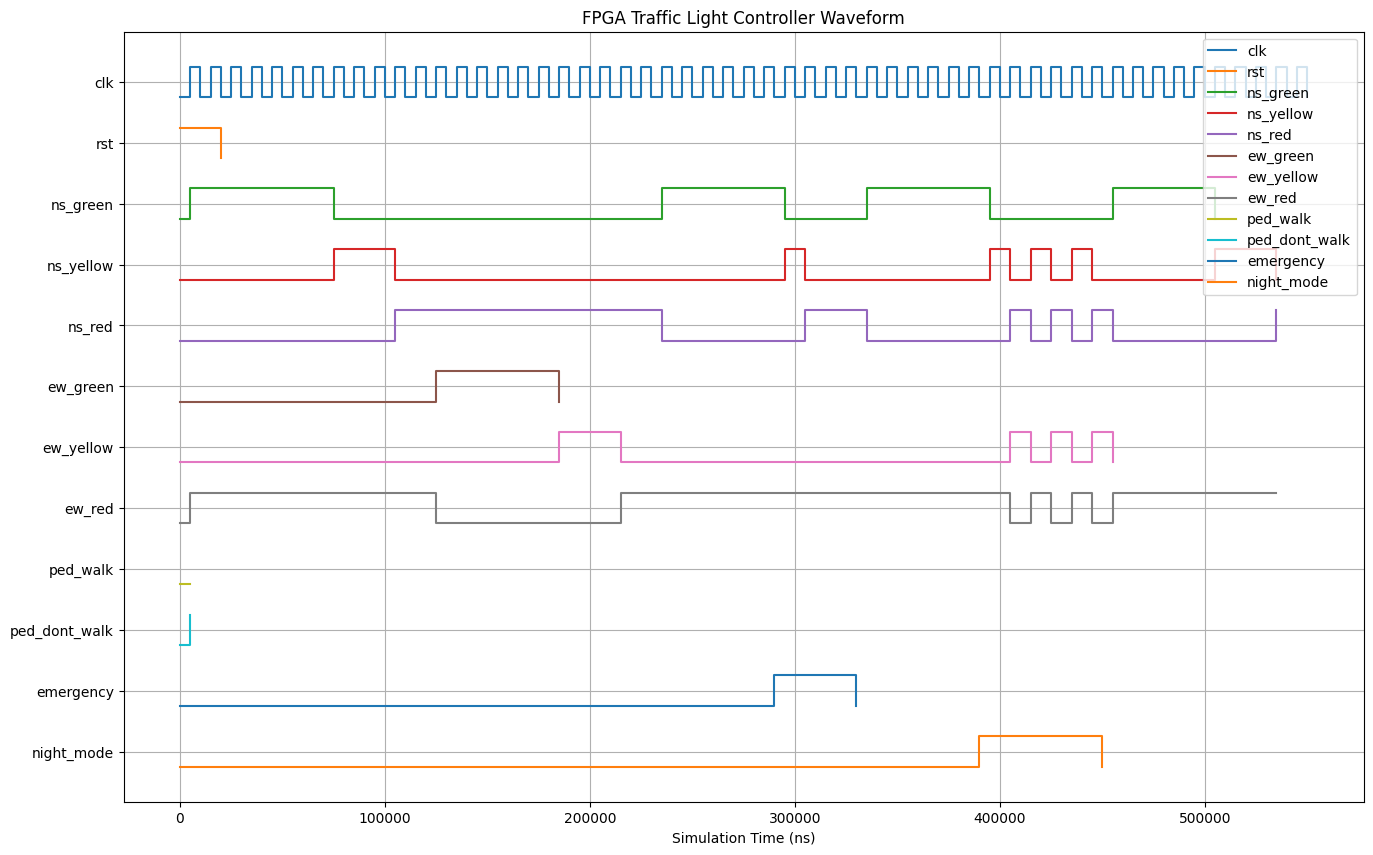

In [ ]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt
import os

vcd_file = "waveforms/traffic_light.vcd"

# Read waveform file
vcd = VCDVCD(vcd_file, store_tvs=True)

# Signals to display
signals = [
    "traffic_light_tb.clk",
    "traffic_light_tb.rst",
    "traffic_light_tb.ns_green",
    "traffic_light_tb.ns_yellow",
    "traffic_light_tb.ns_red",
    "traffic_light_tb.ew_green",
    "traffic_light_tb.ew_yellow",
    "traffic_light_tb.ew_red",
    "traffic_light_tb.ped_walk",
    "traffic_light_tb.ped_dont_walk",
    "traffic_light_tb.emergency",
    "traffic_light_tb.night_mode"
]

plt.figure(figsize=(16, 10))

for index, signal_name in enumerate(signals):
    if signal_name not in vcd.signals:
        print(f"Signal not found: {signal_name}")
        continue

    tv = vcd[signal_name].tv
    times = [item[0] for item in tv]
    values = [int(item[1]) if item[1] in ['0', '1'] else 0 for item in tv]

    # Extend the final value so the waveform remains visible
    if len(times) > 0:
        times.append(times[-1] + 10)
        values.append(values[-1])

    plt.step(
        times,
        [value + (len(signals) - index - 1) * 2 for value in values],
        where="post",
        label=signal_name.split(".")[-1]
    )

plt.yticks(
    [(len(signals) - i - 1) * 2 + 0.5 for i in range(len(signals))],
    [signal.split(".")[-1] for signal in signals]
)

plt.xlabel("Simulation Time (ns)")
plt.title("FPGA Traffic Light Controller Waveform")
plt.grid(True)
plt.legend(loc="upper right")

# Save waveform image
os.makedirs("waveforms", exist_ok=True)
plt.savefig("waveforms/traffic_light_waveform.png", dpi=300, bbox_inches="tight")

# Display waveform directly in Colab
plt.show()

In [ ]:
from google.colab import files

files.download("waveforms/traffic_light_waveform.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print("Generated project files:\n")

for root, dirs, files_list in os.walk("."):
    level = root.replace(".", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)
    for file in files_list:
        print(f"{sub_indent}{file}")

Generated project files:

./
    reports/
    rtl/
        traffic_light_controller.v
    tb/
        traffic_light_tb.v
    waveforms/
        traffic_light.vcd
        traffic_light_waveform.png
    simulation/
        traffic_sim
